In [160]:
# imports
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [161]:
# Load the csv file
df = pd.read_csv('data/data.csv')

feature_names = df.columns[:-1].to_list()
features = df.iloc[:, :-1].values
labels = df.iloc[:, -1].values
classes = np.unique(labels)

In [162]:
distance_matrix = np.zeros((len(features), len(features)))
for i in range(len(features)):
    for j in range(i + 1, len(features)):
        distance_matrix[i, j] = np.linalg.norm(features[i] - features[j])
        distance_matrix[j, i] = distance_matrix[i, j]

In [163]:
# ECM clustering
from evclust.ecm import ecm
model = ecm(x=features, c=2, beta = 1.3,  alpha=1, delta=3, disp=False)

F = model['F']
M = model['mass']

focal_sets = [" \\cup ".join(["\\omega_{" + str(i+1) + "}" for i in range(len(f)) if f[i] == 1]) for f in F]
focal_sets[0] = "\emptyset"
focal_sets = ['$'+f+'$' for f in focal_sets]

In [164]:
def jaccard_matrix_calculus(number_metaclasses):
    """
    Compute the Jaccard matrix for the disernment framework of the given mass function
    """
    natoms = round(np.log2(number_metaclasses))
    ind = [{}]*number_metaclasses
    if (np.power(2, natoms) == number_metaclasses):
        ind[0] = {0} #In fact, the first element should be a None value (for empty set).
        #But in the following calculate, we'll deal with 0/0 which shoud be 1 bet in fact not calculable. So we "cheat" here to make empty = {0}
        ind[1] = {1}
        step = 2
        while (step < number_metaclasses):
            ind[step] = {step}
            step = step+1
            indatom = step
            for step2 in range(1,indatom - 1):
                ind[step] = (ind[step2] | ind[indatom-1])
                step = step+1
    out = np.zeros((number_metaclasses,number_metaclasses))

    for i in range(number_metaclasses):
        for j in range(number_metaclasses):
            out[i][j] = float(len(ind[i] & ind[j]))/float(len(ind[i] | ind[j]))

    out[0,0] = 0
    return out


In [165]:
S_1 = jaccard_matrix_calculus(M.shape[1])
upper_diagonal_ones = np.triu(np.ones((S_1.shape[0], S_1.shape[1])), k=0)
upper_S_1 = S_1 * upper_diagonal_ones
down_S_1 = upper_S_1.T

similarities_dict = {
    "$S^\infty$": np.eye(S_1.shape[0]),
    # "$S^0$": np.ceil(S_1),
    # "$S^1$": S_1,
    # "$S^2$": S_1**2,
    # "$\overline{S}^0$": np.ceil(upper_S_1),
    # "$\overline{S}^1$": upper_S_1,
    # "$\overline{S}^2$": upper_S_1**2,
    r"${S}^0$": np.ceil(S_1),
    r"${S}^1$": S_1,
    r"${S}^2$": S_1**2,
    r"${S}^{0.1}$": S_1**0.1,
}

In [166]:
similarities = list(similarities_dict.values())
similarity_names = list(similarities_dict.keys())

In [167]:
def cohesion(i, distance_matrix, mass_compatibility_fn, mass):
    output_num = 0
    output_den = 0
    for j in range(mass.shape[0]):
        weight = mass_compatibility_fn(mass[i, :], mass[j, :])

        # calc the distance between the two points
        dist = distance_matrix[i, j]

        # update the numerator and denominator
        output_num += weight * dist
        output_den += weight
    return output_num / output_den

In [ ]:
def get_compatibility(similarity_matrix):
    def mass_compatibility_fn(m_i, m_j):
        product = np.dot(np.dot(m_i, similarity_matrix), m_j)
        product /= np.dot(np.dot(m_i, similarity_matrix), m_i)
        if np.isnan(product) or np.isinf(product):
            return 0
        return product
    return mass_compatibility_fn

In [169]:
def sillhouette(i, distance_matrix, similarity, mass):
    a = cohesion(i, distance_matrix, get_compatibility(similarity), mass)
    b = cohesion(i, distance_matrix, get_compatibility(1 - similarity), mass)
    return (b - a) / max(a, b)

In [170]:
def plot_parameters(alpha, beta, delta, ax):
    model = ecm(x=features, c=2, beta = beta,  alpha=alpha, delta=delta, disp=False)
    memberships = model['mass']
    N = memberships.shape[1]

    # get list of colors 
    cmap = plt.get_cmap('Set1')

    def_avg_sillhouettes = [np.mean([sillhouette(i, distance_matrix, similarity, memberships) for i in range(len(features))]) for similarity in similarities]
    str_avg_sillhouettes = [f'{similarity_names[n]} = {s:.2f}' for n, s in enumerate(def_avg_sillhouettes)]
    str_avg_sillhouettes = '\n'.join(str_avg_sillhouettes)

    ax.set_yticks([])
    ax.set_xticks([])

    for point in range(len(features)):
        color = np.sum([np.array(cmap(i)) * memberships[point, i] for i in range(N)], axis=0)
        color = np.clip(color, 0, 1)
    
        ax.scatter(features[point, 0], features[point, 1], c=[color], edgecolors='k')

    ax.set_title(f'$\\alpha={alpha}$, $\\beta={beta}$, $\\delta={delta}$\n{str_avg_sillhouettes}')

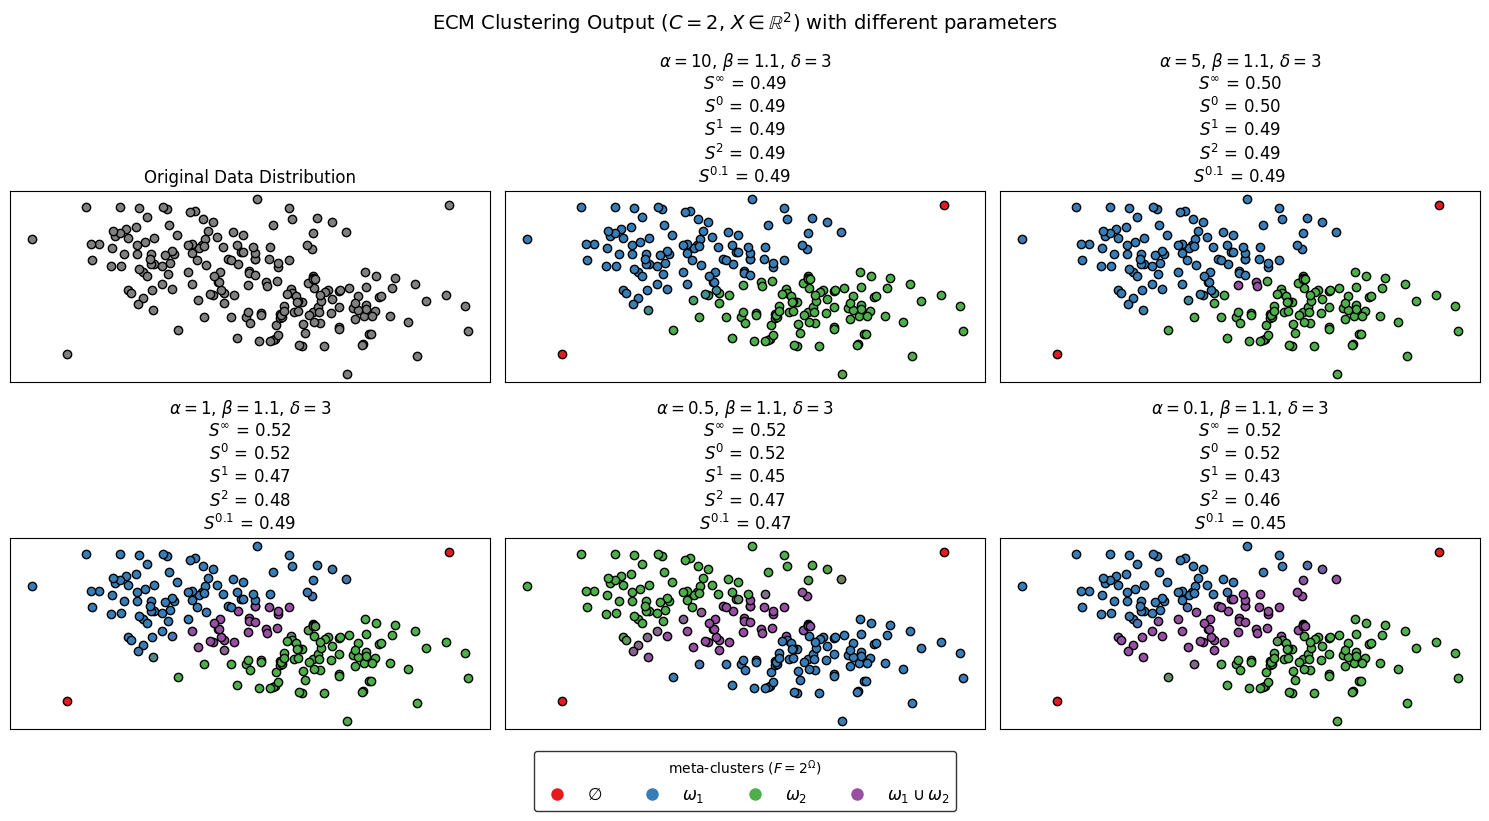

In [171]:
pars = [
    (10, 1.1, 3),
    (5, 1.1, 3),
    (1, 1.1, 3),
    (0.5, 1.1, 3),
    (0.1, 1.1, 3),
]

fig, axs = plt.subplots(2, 3, figsize=(15, 7.5))


# scatter in gray
for point in range(len(features)):
    axs[0, 0].scatter(features[point, 0], features[point, 1], c='gray', edgecolors='k')
    axs[0, 0].set_yticks([])
    axs[0, 0].set_xticks([])
    axs[0, 0].set_title('Original Data Distribution')

for i in range(len(pars)):
    i +=1
    plot_parameters(*pars[i-1], axs[i//3, i%3])

fig.suptitle('ECM Clustering Output ($C=2$, $X \in \mathbb{R}^2$) with different parameters', fontsize=14)

fig.tight_layout()

fig.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label=focal_sets[i], 
                                    markerfacecolor=plt.get_cmap('Set1')(i), markersize=10) for i in range(len(focal_sets))],edgecolor='black', 
                loc='lower center', ncol=len(focal_sets), fontsize='large', title='meta-clusters ($F = 2^\Omega$)', bbox_to_anchor=(0.5, -0.1))
        


In [172]:
# pars_default = (1, 2, 3)
pars_default = (1, 1.1, 3)

# var pars and measure sillhouettes
sillhouettes = []

# variate alpha
# for alpha in [0.1, 0.5, 1, 2, 5, 10]:
for alpha in np.linspace(0.01, 6, 100):
    try:
        model = ecm(x=features, c=2, beta = pars_default[1],  alpha=alpha, delta=pars_default[2], disp=False)
        memberships = model['mass']
        out = [np.mean([sillhouette(i, distance_matrix, sim, memberships) for i in range(M.shape[0])]) for sim in similarities]
        out = {f'{similarity_names[n]}': s for n, s in enumerate(out)}
        sillhouettes.append({'alpha': alpha, 'beta': pars_default[1], 'delta': pars_default[2], **out})
    except:
        pass

# variate beta
# for beta in [1.01, 1.1, 1.5, 2, 5, 10]:
for beta in np.linspace(1.01, 8, 40):
    try:
        model = ecm(x=features, c=2, beta = beta,  alpha=pars_default[0], delta=pars_default[2], disp=False)
        memberships = model['mass']
        out = [np.mean([sillhouette(i, distance_matrix, sim, memberships) for i in range(M.shape[0])]) for sim in similarities]
        out = {f'{similarity_names[n]}': s for n, s in enumerate(out)}
        sillhouettes.append({'alpha': pars_default[0], 'beta': beta, 'delta': pars_default[2], **out})
    except:
        pass
    
# variate delta
# for delta in [0.1, 0.5, 1, 2, 5, 10]:
for delta in np.linspace(0.1, 8, 100):
    try:
        model = ecm(x=features, c=2, beta = pars_default[1],  alpha=pars_default[0], delta=delta, disp=False)
        memberships = model['mass']
        out = [np.mean([sillhouette(i, distance_matrix, sim, memberships) for i in range(M.shape[0])]) for sim in similarities]
        out = {f'{similarity_names[n]}': s for n, s in enumerate(out)}
        sillhouettes.append({'alpha': pars_default[0], 'beta': pars_default[1], 'delta': delta, **out})
    except:
        pass

sillhouettes = pd.DataFrame(sillhouettes)
sillhouettes

/Users/victor/Documents/GitHub/clustering-examples/.venv/lib/python3.9/site-packages/evclust/ecm.py:121: RuntimeWarning: overflow encountered in power
  vect1 = (np.tile(D[i, j], f-1) / vect0) ** (1 / (beta-1))
/Users/victor/Documents/GitHub/clustering-examples/.venv/lib/python3.9/site-packages/evclust/ecm.py:123: RuntimeWarning: overflow encountered in multiply
  vect3 = vect1 * vect2
/Users/victor/Documents/GitHub/clustering-examples/.venv/lib/python3.9/site-packages/evclust/utils.py:205: RuntimeWarning: divide by zero encountered in divide
  C = 1 / (1 - conf)
/var/folders/qn/sypqqw3101v1k6_70wqyd99h0000gn/T/ipykernel_29358/3735576476.py:4: RuntimeWarning: divide by zero encountered in scalar divide
  product /= np.dot(np.dot(m_i, similarity_matrix), m_i)
/var/folders/qn/sypqqw3101v1k6_70wqyd99h0000gn/T/ipykernel_29358/3735576476.py:4: RuntimeWarning: invalid value encountered in scalar divide
  product /= np.dot(np.dot(m_i, similarity_matrix), m_i)
/var/folders/qn/sypqqw3101v1k6_70

,alpha,beta,delta,$S^\infty$,${S}^0$,${S}^1$,${S}^2$,${S}^{0.1}$
0,0.010000,1.1,3.000000,0.520501,0.521094,0.429621,0.455604,0.449943
1,0.070505,1.1,3.000000,0.521520,0.521228,0.432274,0.457529,0.452139
2,0.131010,1.1,3.000000,0.522307,0.521054,0.434624,0.459153,0.454210
3,0.191515,1.1,3.000000,0.522837,0.520561,0.436726,0.460506,0.456164
4,0.252020,1.1,3.000000,0.523116,0.519787,0.438701,0.461675,0.458050
...,...,...,...,...,...,...,...,...
235,1.000000,1.1,7.680808,0.507999,0.493488,0.457984,0.465259,0.465392
236,1.000000,1.1,7.760606,0.507999,0.493138,0.457984,0.465259,0.465392
237,1.000000,1.1,7.840404,0.507999,0.492801,0.457984,0.465259,0.465392
238,1.000000,1.1,7.920202,0.507999,0.492479,0.457984,0.465259,0.465392


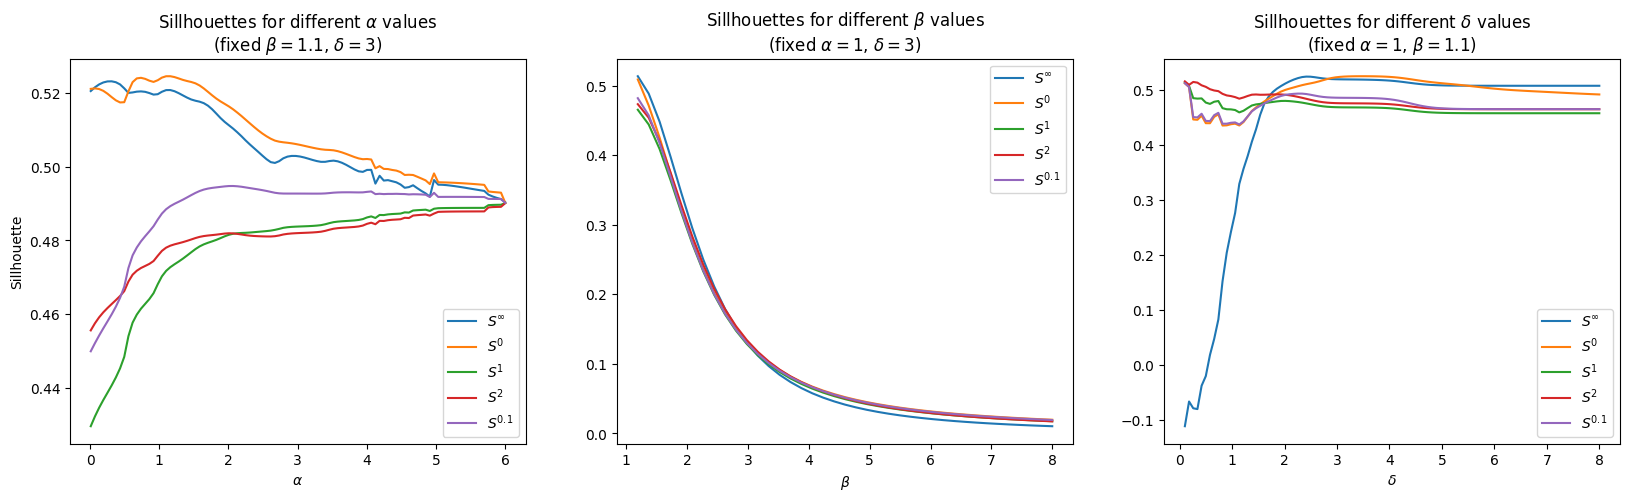

In [173]:
# plot sillhouettes
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

# fix beta and delta
to_plot = sillhouettes[(sillhouettes['beta'] == pars_default[1]) & (sillhouettes['delta'] == pars_default[2])].sort_values('alpha')
for c in to_plot.columns:
    if c == 'alpha' or c == 'beta' or c == 'delta':
        continue
    axs[0].plot(to_plot['alpha'], to_plot[c], label=c)
axs[0].set_title(f'Sillhouettes for different $\\alpha$ values\n(fixed $\\beta={pars_default[1]}$, $\\delta={pars_default[2]}$)')
axs[0].set_xlabel('$\\alpha$')
axs[0].set_ylabel('Sillhouette')
axs[0].legend()
# log scale
# axs[0].set_xscale('log')

# fix alpha and delta
to_plot = sillhouettes[(sillhouettes['alpha'] == pars_default[0]) & (sillhouettes['delta'] == pars_default[2])].sort_values('beta')
for c in to_plot.columns:
    if c == 'alpha' or c == 'beta' or c == 'delta':
        continue
    axs[1].plot(to_plot['beta'], to_plot[c], label=c)
axs[1].set_title(f'Sillhouettes for different $\\beta$ values\n(fixed $\\alpha={pars_default[0]}$, $\\delta={pars_default[2]}$)')
axs[1].set_xlabel('$\\beta$')
axs[1].legend()

# fix alpha and beta
to_plot = sillhouettes[(sillhouettes['alpha'] == pars_default[0]) & (sillhouettes['beta'] == pars_default[1])].sort_values('delta')
for c in to_plot.columns:
    if c == 'alpha' or c == 'beta' or c == 'delta':
        continue
    axs[2].plot(to_plot['delta'], to_plot[c], label=c)
axs[2].set_title(f'Sillhouettes for different $\\delta$ values\n(fixed $\\alpha={pars_default[0]}$, $\\beta={pars_default[1]}$)')
axs[2].set_xlabel('$\\delta$')
axs[2].legend()